In [1]:
# import cmdstanpy
# cmdstanpy.install_cmdstan()

In [39]:
import json
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import datetime
import seaborn as sns
import cmdstanpy
from cmdstanpy import CmdStanModel, cmdstan_path
import arviz as az
from pathlib import Path

from loadData import load_data
from imputeMissing import impute_value

import logging
logging.getLogger("cmdstanpy").setLevel(logging.INFO)
from scipy.integrate import odeint

In [ ]:
# ---- SEIR ODE system --------------------------------------------------------
def seir(state, t, beta, sigma, gamma,mu, N):
    S, E, I, R, D = state
    dS = -beta * S * I / N
    dE =  beta * S * I / N - sigma * E
    dI =  sigma * E - gamma * I
    dR =  gamma * I
    dD = mu*I
    return [dS, dE, dI, dR]


In [ ]:
# Parameters
n_regions = 3  # Guinea, Liberia, Sierra Leone
T = 450  # Time points (days)
N = [11.5e6, 4.5e6, 6.8e6]  # Population per region
beta = [0.3, 0.4, 0.35]  # Transmission rate (R0 = beta/gamma)
sigma = 1/10  # 1/latent period (Ebola: ~10 days) Average value
gamma = 1/7  # 1/infectious period (Ebola: ~7 days)
phi = 10.0  # Negative binomial dispersion parameter
mu = 0.01
reporting_rate = 0.8  # Proportion of cases reported

# Initial conditions
guinea = [N[0]-10, 0, 10, 0]
lib = [N[1]-20, 0, 20, 0]
sir = [N[2]-10, 0, 10, 0]

initial_state = [guinea, lib, sir]

# Time vector
t = np.linspace(0, T-1, T)

In [5]:
initial_state

[[11499990.0, 0, 10, 0], [4499980.0, 0, 20, 0], [6799990.0, 0, 10, 0]]

In [6]:
# Simulate SEIR for each region
states = np.zeros((n_regions, T, 4))
incidence = np.zeros((n_regions, T))

for i in range(n_regions):
    # Solve ODE
    sol = odeint(seir, initial_state[i], t, args=(beta[i], sigma, gamma, N[i]))
    states[i] = sol
    # Incidence = new infections = beta * S * I / N
    incidence[i] = beta[i] * sol[:, 0] * sol[:, 2] / N[i]

In [7]:
# Generate observed cases using negative binomial
observed_cases = np.zeros((n_regions, T), dtype=int)
for i in range(n_regions):
    for t in range(T):
        mean_cases = reporting_rate * incidence[i, t]
        # Negative binomial: r = phi (dispersion), p = phi/(phi + mean)
        p = phi / (phi + mean_cases)
        r = phi
        observed_cases[i, t] = np.random.negative_binomial(r, p)


In [8]:
# Save data to CSV
# Time vector
t = np.linspace(0, T-1, T)
data = {
    'time': np.tile(t, n_regions),
    'country': np.repeat(['Guinea', 'Liberia', 'Sierra Leone'], T),
    'cases': observed_cases.flatten()
}
df = pd.DataFrame(data)
# df.to_csv('synthetic_ebola_data.csv', index=False)

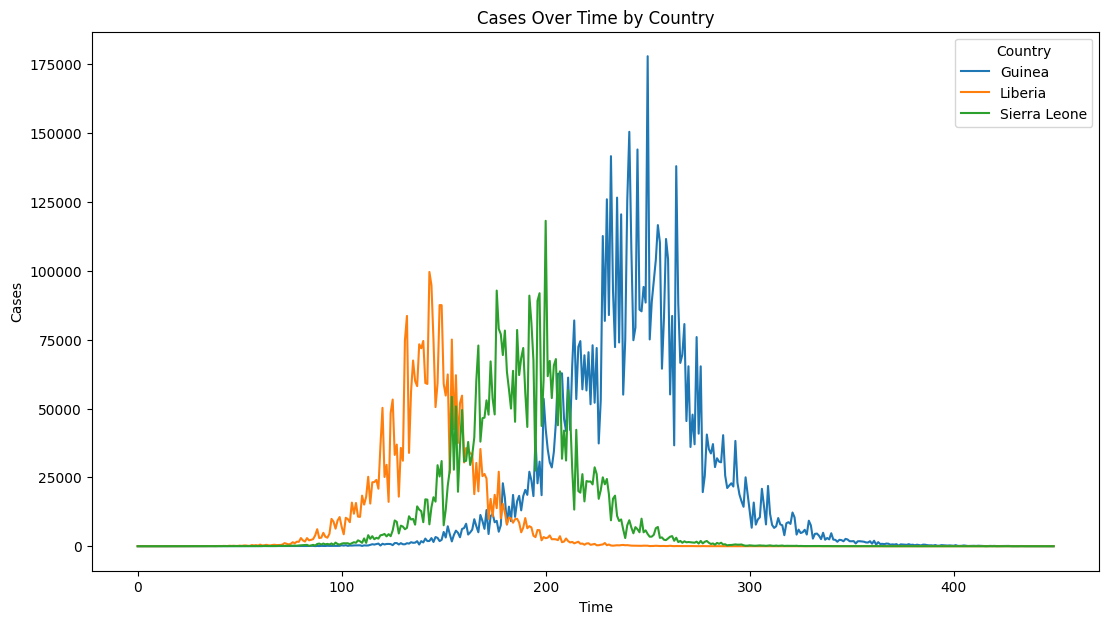

In [9]:
# Group the data by 'country' and plot each group
plt.figure(figsize=(13, 7))
for country, group in df.groupby('country'):
    plt.plot(group['time'], group['cases'], label=country)

# Add labels and legend
plt.xlabel('Time')
plt.ylabel('Cases')
plt.title('Cases Over Time by Country')
plt.legend(title='Country')
plt.show()

In [10]:
# Convert the 'time' column to datetime format, assuming it represents days since 2014-01-01
df["time"] = pd.Timestamp("2014-01-01") + pd.to_timedelta(df["time"], unit="D")

In [11]:
## get patches
patch_names = ["Guinea", "Liberia", "Sierra Leone"]
n_patches = len(patch_names)

# Set the start date to January 1, 2014
start_date =  df["time"].min()
# Calculate the end date from the maximum value in the 'time' column
end_date = df["time"].max()
weeks = pd.date_range(start=start_date, end=end_date, freq="W-MON")
T = len(weeks)

# Create an empty array to store observed cases
I_obs = np.zeros((T, n_patches))
# country_data = df.copy()

# Fill the observed cases array with weekly data for each patch
for i, country in enumerate(patch_names):
    country_data = df[df["country"] == country]
    # Convert the 'time' column to datetime format
    # country_data["time"] = pd.to_datetime(country_data["time"], unit="D")  # Assuming 'time' is in days
    weekly_cases = country_data.groupby(pd.Grouper(key="time", freq="W-MON"))['cases'].sum()
    # weekly_cases.index = pd.to_datetime(weekly_cases.index)
    weekly_cases = weekly_cases.reindex(weeks, fill_value=0)
    I_obs[:, i] = weekly_cases.values

# Create a DataFrame for plotting
time = np.arange(1, T + 1)
data_plot = pd.DataFrame(I_obs, columns=patch_names)
data_plot["Time"] = time
data_plot["Week"] = weeks[:].strftime("%Y-%m-%d")
# Melt the DataFrame for easier plotting
data_plot = data_plot.melt(id_vars=["Time", "Week"], var_name="Patches", value_name="Cases")

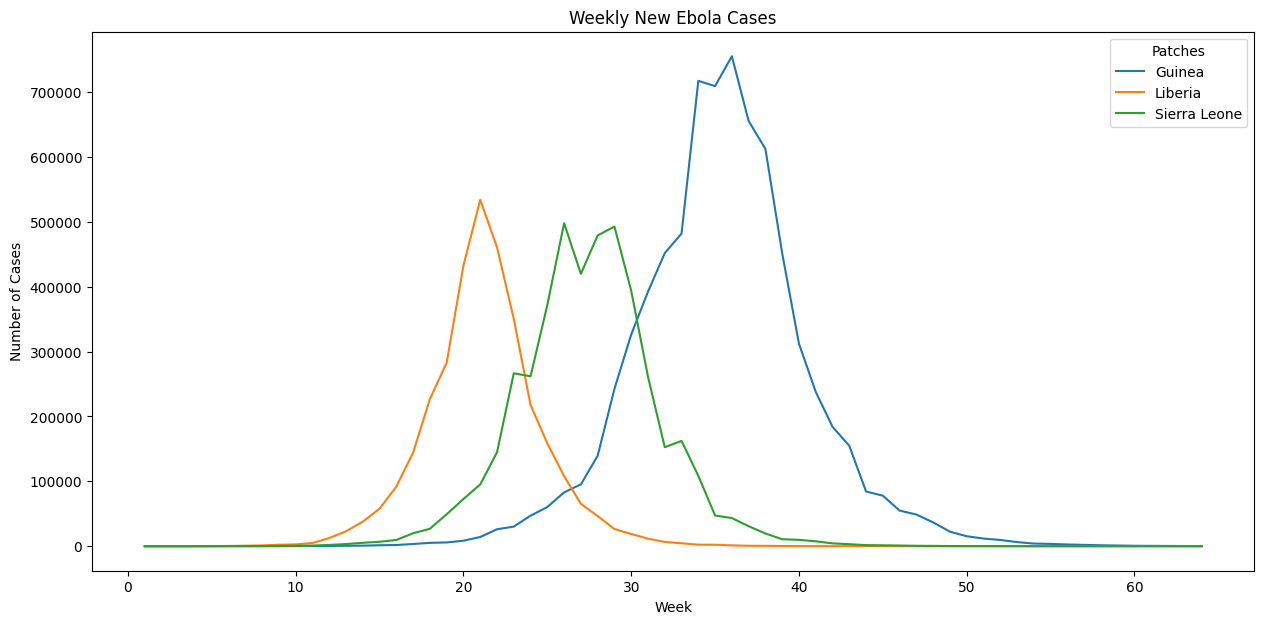

In [12]:
plt.figure(figsize=(15, 7))
sns.lineplot(data=data_plot, x="Time", y="Cases", hue="Patches")
plt.title("Weekly New Ebola Cases")
plt.xlabel("Week")
plt.ylabel("Number of Cases")
# plt.grid(True)
plt.savefig('./images/weekly_cases.pdf', bbox_inches='tight')
plt.show()

In [13]:
# Population sizes (approximate, in millions)
n = np.array([11.5e6, 4.5e6, 6.8e6])  # Guinea, Liberia, Sierra Leone

N = np.sum(n)  # Total population

In [49]:
# Aggregate cases by country and week
countries = ['Guinea', 'Liberia', 'Sierra Leone']
weekly_cases = df.groupby(['country', pd.Grouper(key='time', freq='W')]).sum().unstack(fill_value=0).T
weekly_cases = weekly_cases.reindex(columns=countries, fill_value=0)
cases = weekly_cases.values  # Shape: (T, 3)

data = {
    'P': 3,
    'T': len(cases),
    't0': -1e-3,
    'ts': np.arange(len(cases)),
    'cases': cases,
    'N': [11500000, 4500000, 6800000],
    # 'N': [30000, 500000, 25000]  # Effective population
    'E0': [0, 2, 0],
    'I0': [10, 20, 10]
}

print("Cases shape:", cases.shape)
print("Cases shape:", data_plot.shape)
print("\nFirst few weeks:\n", cases)

Cases shape: (65, 3)
Cases shape: (192, 4)

First few weeks:
 [[    10     26     11]
 [    24     54     15]
 [    13     66     22]
 [    11    105     50]
 [    41    200     54]
 [    66    344     91]
 [    79    678    166]
 [   109   1255    223]
 [    91   2163    364]
 [   236   2680    593]
 [   330   4590    944]
 [   363  11721   1732]
 [   690  21773   2785]
 [   822  31933   5684]
 [  1457  56927   6299]
 [  1891  83293   9522]
 [  2784 138655  18147]
 [  5177 202526  26334]
 [  5925 256456  46759]
 [  8566 433967  65640]
 [ 13326 532273  90783]
 [ 20419 473409 140474]
 [ 31202 358140 239099]
 [ 46106 242087 251181]
 [ 56761 171610 364913]
 [ 76351 113019 486679]
 [ 94607  68921 435966]
 [139600  51210 473670]
 [225495  27213 498392]
 [298705  20461 423783]
 [401626  11796 250781]
 [453595   7418 171337]
 [451597   3884 163393]
 [725095   3219 121831]
 [708334   2401  51815]
 [652097   1336  43678]
 [768807    782  32074]
 [538826    581  19711]
 [553603    402  12483]
 [

In [15]:
# Compile and fit the model
model_synth = CmdStanModel(stan_file="multi_patch.stan")
fit_synth = model_synth.sample(
    data=data,
    chains=4,
    iter_warmup= 500,
    iter_sampling=1000,
    seed=12
)
# Convert to ArviZ InferenceData for analysis
inference_data = az.from_cmdstanpy(fit_synth)

DEBUG:cmdstanpy:found newer exe file, not recompiling
DEBUG:cmdstanpy:cmd: /media/brasammy/5B6DAD9B6A1F7E40/Projects/Thesis/Main/Final_work/thesis/multi_patch info
cwd: None
DEBUG:cmdstanpy:input tempfile: /tmp/tmp1ye5fnox/39f31hz9.json
09:54:58 - cmdstanpy - INFO - CmdStan start processing
INFO:cmdstanpy:CmdStan start processing
chain 1 |          | 00:00 Status


DEBUG:cmdstanpy:idx 0
DEBUG:cmdstanpy:running CmdStan, num_threads: 1
DEBUG:cmdstanpy:idx 1
DEBUG:cmdstanpy:idx 2
DEBUG:cmdstanpy:CmdStan args: ['/media/brasammy/5B6DAD9B6A1F7E40/Projects/Thesis/Main/Final_work/thesis/multi_patch', 'id=1', 'random', 'seed=12', 'data', 'file=/tmp/tmp1ye5fnox/39f31hz9.json', 'output', 'file=/tmp/tmp1ye5fnox/multi_patchi94vbkam/multi_patch-20250513095458_1.csv', 'method=sample', 'num_samples=1000', 'num_warmup=500', 'algorithm=hmc', 'adapt', 'engaged=1']
DEBUG:cmdstanpy:idx 3
DEBUG:cmdstanpy:running CmdStan, num_threads: 1
DEBUG:cmdstanpy:running CmdStan, num_threads: 1
DEBUG:cmdstanpy:running 


10:53:27 - cmdstanpy - INFO - CmdStan done processing.
INFO:cmdstanpy:CmdStan done processing.
DEBUG:cmdstanpy:runset
RunSet: chains=4, chain_ids=[1, 2, 3, 4], num_processes=4
 cmd (chain 1):
	['/media/brasammy/5B6DAD9B6A1F7E40/Projects/Thesis/Main/Final_work/thesis/multi_patch', 'id=1', 'random', 'seed=12', 'data', 'file=/tmp/tmp1ye5fnox/39f31hz9.json', 'output', 'file=/tmp/tmp1ye5fnox/multi_patchi94vbkam/multi_patch-20250513095458_1.csv', 'method=sample', 'num_samples=1000', 'num_warmup=500', 'algorithm=hmc', 'adapt', 'engaged=1']
 retcodes=[0, 0, 0, 0]
 per-chain output files (showing chain 1 only):
 csv_file:
	/tmp/tmp1ye5fnox/multi_patchi94vbkam/multi_patch-20250513095458_1.csv
 console_msgs (if any):
	/tmp/tmp1ye5fnox/multi_patchi94vbkam/multi_patch-20250513095458_0-stdout.txt
DEBUG:cmdstanpy:Chain 1 console:
method = sample (Default)
  sample
    num_samples = 1000 (Default)
    num_warmup = 500
    save_warmup = false (Default)
    thin = 1 (Default)
    adapt
      engaged = 

In [16]:
print(fit_synth.diagnose())

DEBUG:cmdstanpy:cmd: /home/brasammy/.cmdstan/cmdstan-2.36.0/bin/diagnose /tmp/tmp1ye5fnox/multi_patchi94vbkam/multi_patch-20250513095458_1.csv /tmp/tmp1ye5fnox/multi_patchi94vbkam/multi_patch-20250513095458_2.csv /tmp/tmp1ye5fnox/multi_patchi94vbkam/multi_patch-20250513095458_3.csv /tmp/tmp1ye5fnox/multi_patchi94vbkam/multi_patch-20250513095458_4.csv
cwd: None


Checking sampler transitions treedepth.
Treedepth satisfactory for all transitions.

Checking sampler transitions for divergences.
No divergent transitions found.

Checking E-BFMI - sampler transitions HMC potential energy.
The E-BFMI, 0.01, is below the nominal threshold of 0.30 which suggests that HMC may have trouble exploring the target distribution.
If possible, try to reparameterize the model.

Rank-normalized split effective sample size satisfactory for all parameters.

The following parameters had rank-normalized split R-hat greater than 1.01:
  sigma, gamma, beta[1], beta[2], beta[3], phi_inv, rho[1], rho[2], rho[3], incidence[1,1], incidence[2,1], incidence[3,1], incidence[4,1], incidence[5,1], incidence[6,1], incidence[7,1], incidence[8,1], incidence[9,1], incidence[10,1], incidence[11,1], incidence[12,1], incidence[13,1], incidence[14,1], incidence[15,1], incidence[16,1], incidence[17,1], incidence[18,1], incidence[19,1], incidence[20,1], incidence[21,1], incidence[22,1], i

In [17]:
fit_synth.summary()

DEBUG:cmdstanpy:cmd: /home/brasammy/.cmdstan/cmdstan-2.36.0/bin/stansummary --percentiles= 5,50,95 --sig_figs=6 --csv_filename=/tmp/tmp1ye5fnox/stansummary-multi_patch-mdxatwlg.csv /tmp/tmp1ye5fnox/multi_patchi94vbkam/multi_patch-20250513095458_1.csv /tmp/tmp1ye5fnox/multi_patchi94vbkam/multi_patch-20250513095458_2.csv /tmp/tmp1ye5fnox/multi_patchi94vbkam/multi_patch-20250513095458_3.csv /tmp/tmp1ye5fnox/multi_patchi94vbkam/multi_patch-20250513095458_4.csv
cwd: None


,Mean,MCSE,StdDev,MAD,5%,50%,95%,ESS_bulk,ESS_tail,R_hat
lp__,-2107.840000,21.050400,29.885800,3.624960,-2161.120000,-2091.270000,-2087.690000,7.21380,2000.0000,1.53268
sigma,3.444290,0.191964,0.453196,0.335320,2.889720,3.355530,4.381790,16.95850,2000.0000,1.16516
gamma,0.606253,0.232196,0.329749,0.048678,0.034695,0.783097,0.843108,7.25203,2000.0000,1.52896
beta[1],1.107220,0.247898,0.351791,0.043596,0.490766,1.297440,1.352230,7.25726,2000.0000,1.52987
beta[2],1.408970,0.277131,0.393124,0.042766,0.715379,1.623520,1.675920,7.24770,2000.0000,1.52873
...,...,...,...,...,...,...,...,...,...,...
"predicted_cases[64,2]",0.040500,NaN,0.216498,0.000000,0.000000,0.000000,0.000000,NaN,NaN,NaN
"predicted_cases[64,3]",2.011000,1.196140,2.649460,1.482600,0.000000,1.000000,7.000000,11.66050,68.3492,1.24741
"predicted_cases[65,1]",189.345000,31.358500,98.252700,40.771500,105.000000,167.500000,374.050000,69.47440,93.0743,1.20938
"predicted_cases[65,2]",0.032500,0.027558,0.186956,0.000000,0.000000,0.000000,0.000000,95.41640,92.3879,1.04053


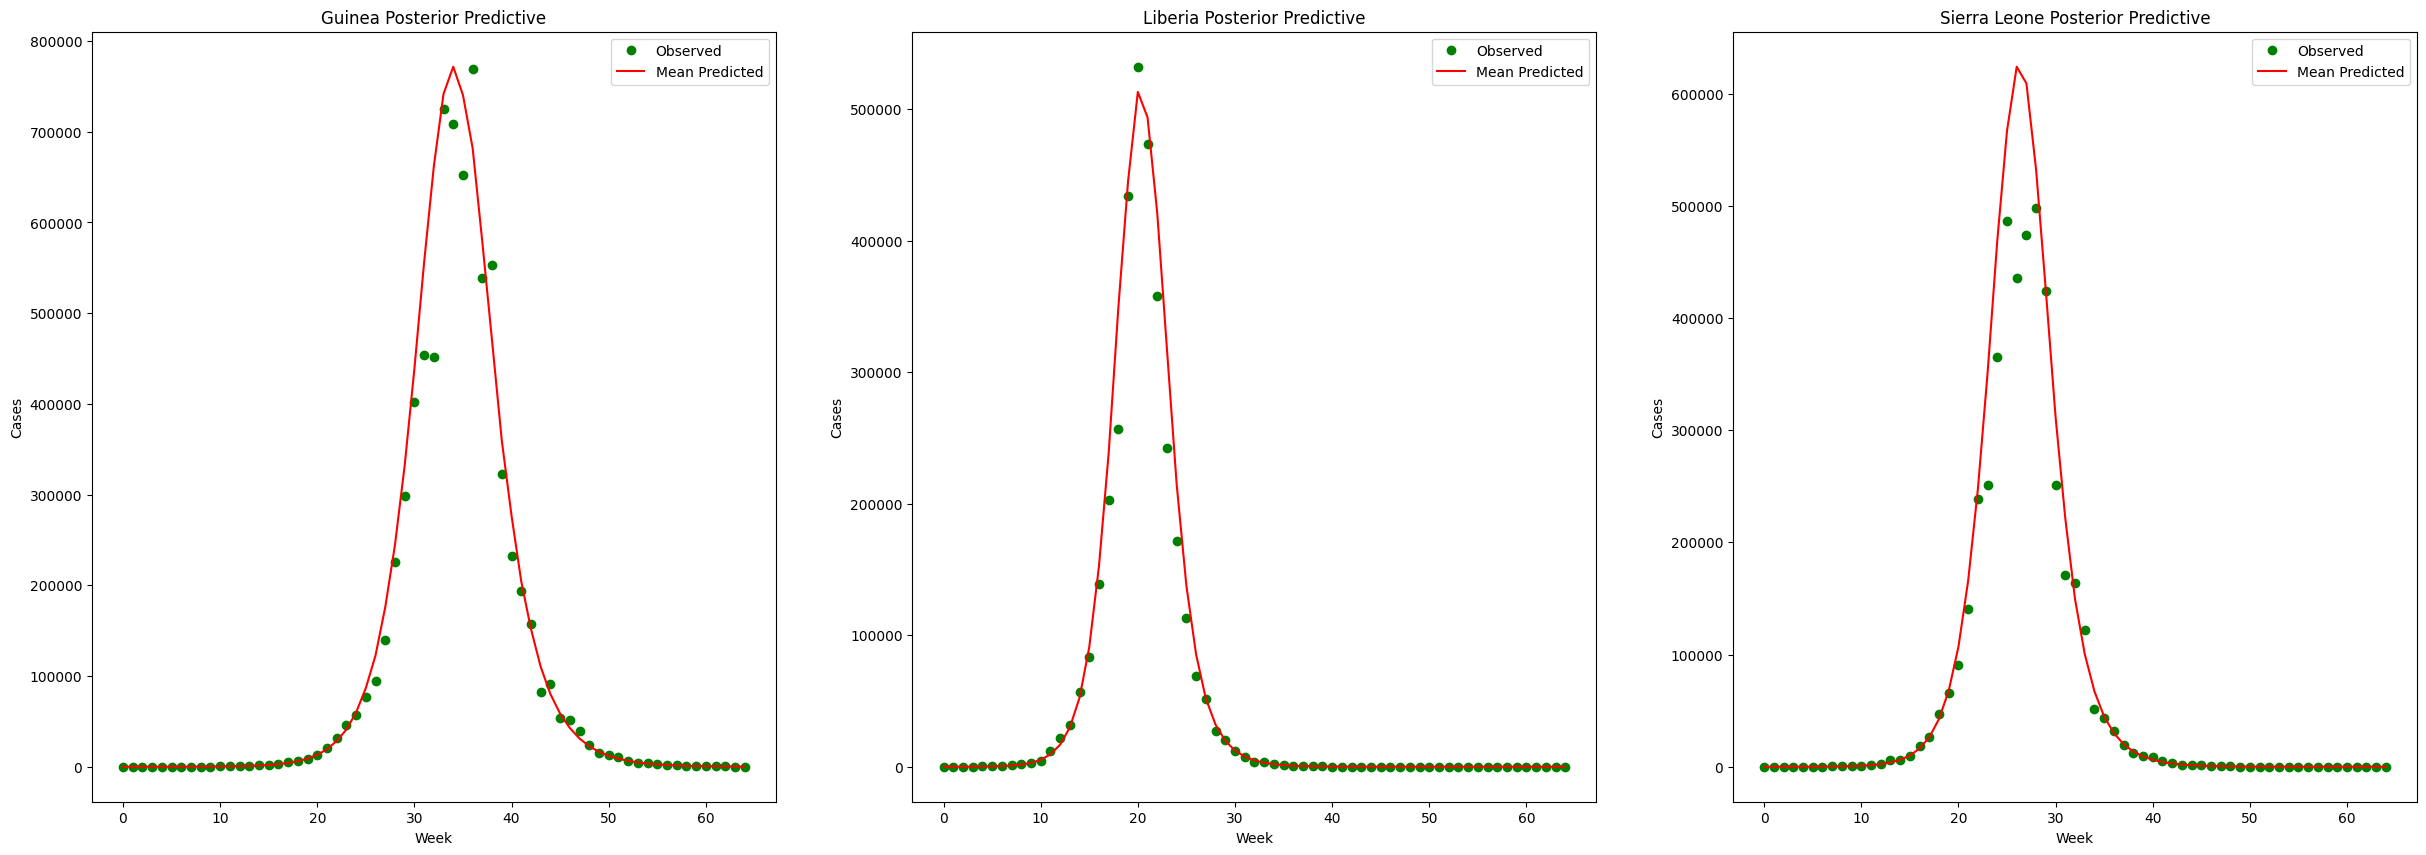

In [18]:
import matplotlib.pyplot as plt
predicted_cases = fit_synth.stan_variable('predicted_cases')  # Shape: (samples, T, P)

## subplot (1,3)
fig, axes = plt.subplots(1, 3, figsize=(30, 10))
for p, country in enumerate(countries):
    # for i in range(400):
    #     plt.plot(data['ts'], predicted_cases[i, :, p], alpha=0.1, color='blue')
    axes[p].plot(data['ts'], data['cases'][:, p], 'o', label='Observed', color='green')
    axes[p].plot(data['ts'], predicted_cases.mean(axis=0)[:, p], label='Mean Predicted', color='red')
    axes[p].set_title(f'{country} Posterior Predictive')
    axes[p].set_xlabel('Week')
    axes[p].set_ylabel('Cases')
    axes[p].legend()
plt.show()

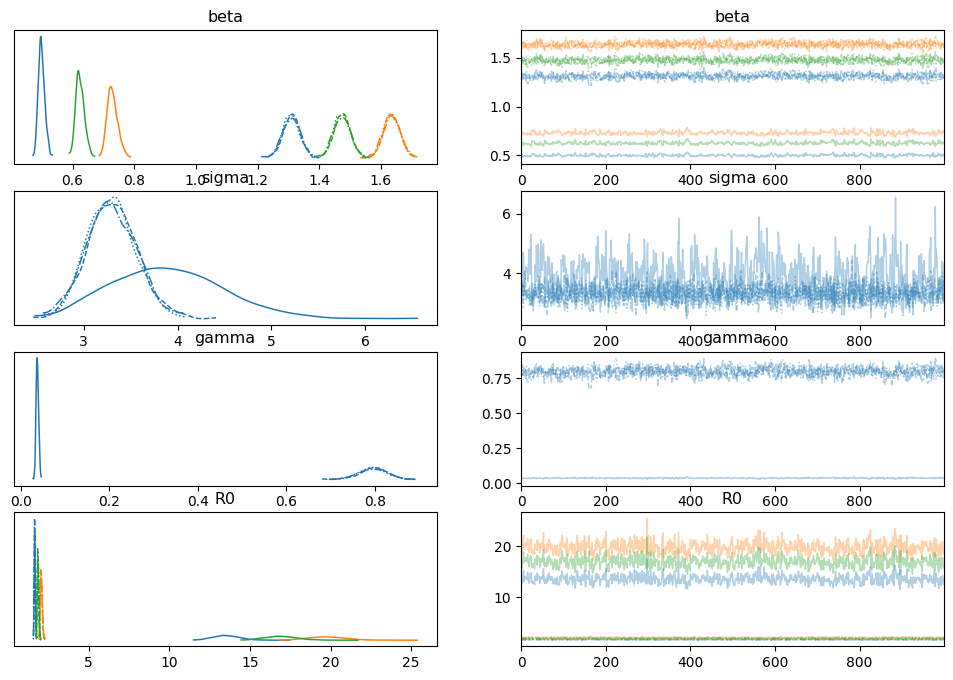

In [19]:
## trace plots
az.plot_trace(fit_synth, var_names=["beta", "sigma", "gamma", "R0"])
plt.show()

# Posterior Predictive Checks

Available variables: dict_keys(['sigma', 'gamma', 'beta', 'phi_inv', 'rho', 'incidence', 'phi', 'theta', 'R0', 'predicted_cases'])


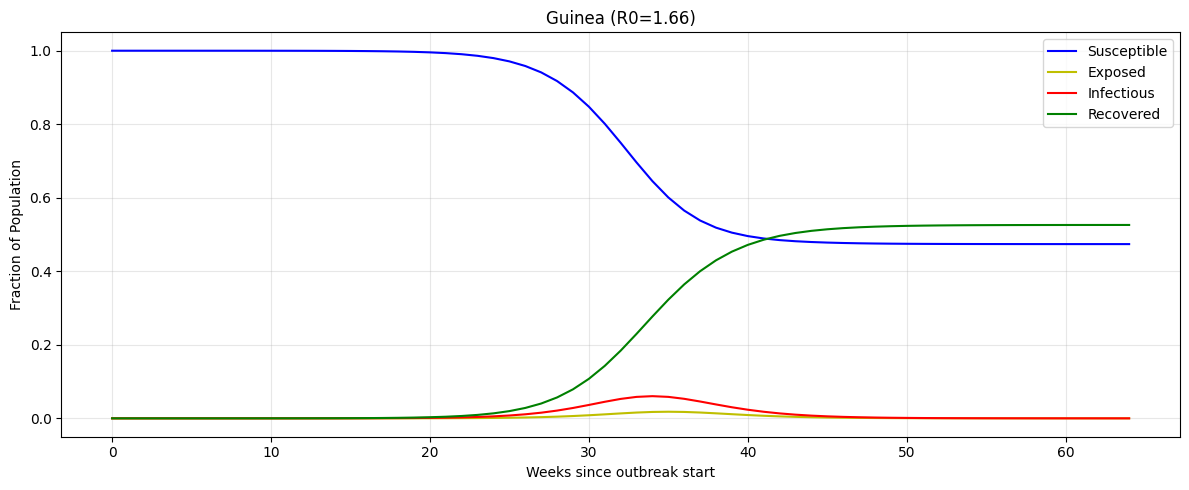

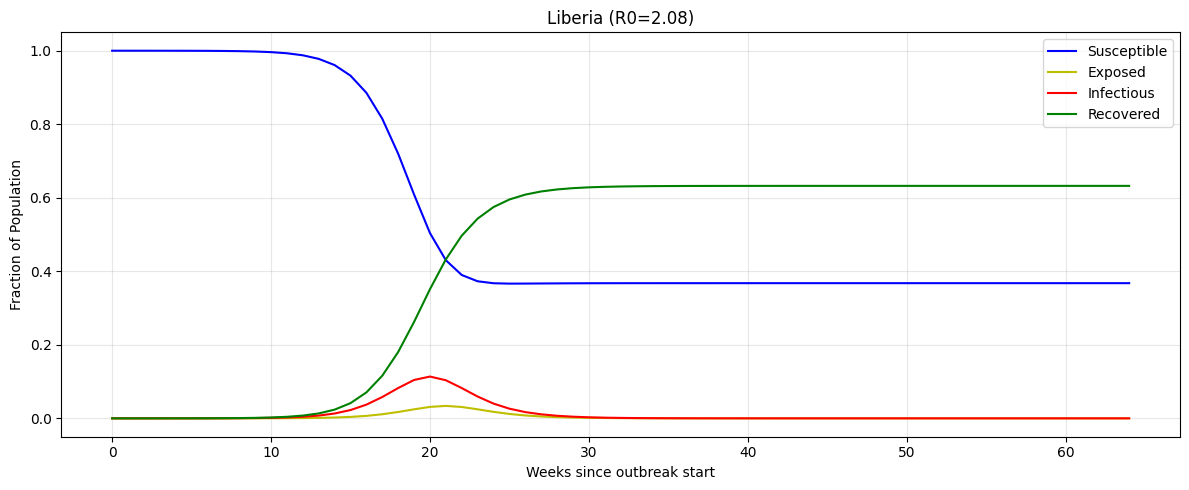

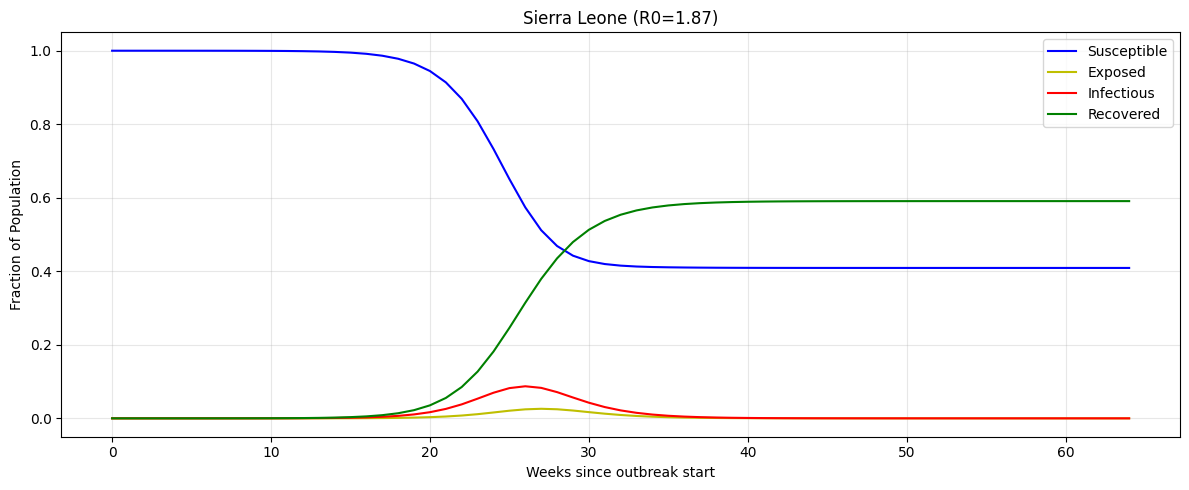

In [20]:
# Get available variables
print("Available variables:", fit_synth.stan_variables().keys())

# Time points and countries
weeks = np.arange(fit_synth.stan_variable('incidence').shape[1])  # Number of weeks
countries = ['Guinea', 'Liberia', 'Sierra Leone']



# Plot incidence (infectious) and reconstructed other compartments
for i, (country) in enumerate(countries):

    # Create figure
    fig, axes = plt.subplots(1, 1, figsize=(12, 5), sharex=True)
        # Get median incidence
    incidence = np.median(fit_synth.stan_variable('incidence')[:, :, i], axis=0)

    # Reconstruct approximate compartments (scaled by reporting rate)
    rho = np.median(fit_synth.stan_variable('rho')[:, i])
    I = incidence / rho
    R = np.cumsum(I) * np.median(fit_synth.stan_variable('gamma'))
    E = np.roll(I, 1) / np.median(fit_synth.stan_variable('sigma'))  # Exposed ~ delayed infectious
    E[0] = 0
    S = data['N'][i] - E - I - R

    # Convert to fractions
    S_frac = S / data['N'][i]
    E_frac = E / data['N'][i]
    I_frac = I / data['N'][i]
    R_frac = R / data['N'][i]

    # Plot
    plt.plot(weeks, S_frac, 'b', label='Susceptible')
    plt.plot(weeks, E_frac, 'y', label='Exposed')
    plt.plot(weeks, I_frac, 'r', label='Infectious')
    plt.plot(weeks, R_frac, 'g', label='Recovered')

    # Formatting
    plt.title(f'{country} (R0={np.median(fit_synth.stan_variable("R0")[:, i]):.2f})')
    plt.ylabel('Fraction of Population')
    plt.grid(True, alpha=0.3)
    # ax.set_ylim(0, 1)

    plt.legend(loc='upper right')

    plt.xlabel('Weeks since outbreak start')
    plt.tight_layout()
    plt.show()

In [21]:
# p = fit_synth.summary()
# p.filter(like="y_pred", axis=0)

In [24]:
# Compile and fit the model
model_coupling = CmdStanModel(stan_file="coupling.stan")
fit_coupling = model_coupling.sample(
    data=data,
    chains=4,
    iter_warmup= 10,
    iter_sampling=10,
    seed=12
)
# Convert to ArviZ InferenceData for analysis
inference_data = az.from_cmdstanpy(fit_coupling)

11:45:02 - cmdstanpy - INFO - compiling stan file /media/brasammy/5B6DAD9B6A1F7E40/Projects/Thesis/Main/Final_work/thesis/coupling.stan to exe file /media/brasammy/5B6DAD9B6A1F7E40/Projects/Thesis/Main/Final_work/thesis/coupling
INFO:cmdstanpy:compiling stan file /media/brasammy/5B6DAD9B6A1F7E40/Projects/Thesis/Main/Final_work/thesis/coupling.stan to exe file /media/brasammy/5B6DAD9B6A1F7E40/Projects/Thesis/Main/Final_work/thesis/coupling
DEBUG:cmdstanpy:cmd: make STANCFLAGS+=--filename-in-msg=coupling.stan /media/brasammy/5B6DAD9B6A1F7E40/Projects/Thesis/Main/Final_work/thesis/coupling
cwd: /home/brasammy/.cmdstan/cmdstan-2.36.0
DEBUG:cmdstanpy:Console output:

--- Translating Stan model to C++ code ---
bin/stanc --filename-in-msg=coupling.stan --o=/media/brasammy/5B6DAD9B6A1F7E40/Projects/Thesis/Main/Final_work/thesis/coupling.hpp /media/brasammy/5B6DAD9B6A1F7E40/Projects/Thesis/Main/Final_work/thesis/coupling.stan

--- Compiling C++ code ---
g++ -std=c++17 -pthread -D_REENTRANT -Wno


12:03:56 - cmdstanpy - INFO - CmdStan done processing.
INFO:cmdstanpy:CmdStan done processing.
DEBUG:cmdstanpy:runset
RunSet: chains=4, chain_ids=[1, 2, 3, 4], num_processes=4
 cmd (chain 1):
	['/media/brasammy/5B6DAD9B6A1F7E40/Projects/Thesis/Main/Final_work/thesis/coupling', 'id=1', 'random', 'seed=12', 'data', 'file=/tmp/tmp1ye5fnox/i8ercn1e.json', 'output', 'file=/tmp/tmp1ye5fnox/couplingvvcoasbd/coupling-20250513114521_1.csv', 'method=sample', 'num_samples=10', 'num_warmup=10', 'algorithm=hmc', 'adapt', 'engaged=1']
 retcodes=[0, 0, 0, 0]
 per-chain output files (showing chain 1 only):
 csv_file:
	/tmp/tmp1ye5fnox/couplingvvcoasbd/coupling-20250513114521_1.csv
 console_msgs (if any):
	/tmp/tmp1ye5fnox/couplingvvcoasbd/coupling-20250513114521_0-stdout.txt
DEBUG:cmdstanpy:Chain 1 console:
method = sample (Default)
  sample
    num_samples = 10
    num_warmup = 10
    save_warmup = false (Default)
    thin = 1 (Default)
    adapt
      engaged = true (Default)
      gamma = 0.05 (De

In [25]:
print(fit_coupling.diagnose())

DEBUG:cmdstanpy:cmd: /home/brasammy/.cmdstan/cmdstan-2.36.0/bin/diagnose /tmp/tmp1ye5fnox/couplingvvcoasbd/coupling-20250513114521_1.csv /tmp/tmp1ye5fnox/couplingvvcoasbd/coupling-20250513114521_2.csv /tmp/tmp1ye5fnox/couplingvvcoasbd/coupling-20250513114521_3.csv /tmp/tmp1ye5fnox/couplingvvcoasbd/coupling-20250513114521_4.csv
cwd: None


Checking sampler transitions treedepth.
Treedepth satisfactory for all transitions.

Checking sampler transitions for divergences.
30 of 10 (300.00%) transitions ended with a divergence.
These divergent transitions indicate that HMC is not fully able to explore the posterior distribution.
Try increasing adapt delta closer to 1.
If this doesn't remove all divergences, try to reparameterize the model.

Checking E-BFMI - sampler transitions HMC potential energy.
The E-BFMI, 0.16, is below the nominal threshold of 0.30 which suggests that HMC may have trouble exploring the target distribution.
If possible, try to reparameterize the model.

Rank-normalized split effective sample size satisfactory for all parameters.

The following parameters had rank-normalized split R-hat greater than 1.01:
  predicted_cases[3,1], predicted_cases[5,1], predicted_cases[6,1], predicted_cases[7,1], predicted_cases[8,1], predicted_cases[9,1], predicted_cases[10,1], predicted_cases[11,1], predicted_cases[12,1],

In [53]:
fit_coupling.stan_variable

<bound method CmdStanMCMC.stan_variable of CmdStanMCMC: model=coupling chains=4['method=sample', 'num_samples=10', 'num_warmup=10', 'algorithm=hmc', 'adapt', 'engaged=1']
 csv_files:
	/tmp/tmp1ye5fnox/couplingvvcoasbd/coupling-20250513114521_1.csv
	/tmp/tmp1ye5fnox/couplingvvcoasbd/coupling-20250513114521_2.csv
	/tmp/tmp1ye5fnox/couplingvvcoasbd/coupling-20250513114521_3.csv
	/tmp/tmp1ye5fnox/couplingvvcoasbd/coupling-20250513114521_4.csv
 output_files:
	/tmp/tmp1ye5fnox/couplingvvcoasbd/coupling-20250513114521_0-stdout.txt
	/tmp/tmp1ye5fnox/couplingvvcoasbd/coupling-20250513114521_1-stdout.txt
	/tmp/tmp1ye5fnox/couplingvvcoasbd/coupling-20250513114521_2-stdout.txt
	/tmp/tmp1ye5fnox/couplingvvcoasbd/coupling-20250513114521_3-stdout.txt>

In [ ]:
fitpatch = cmdstanpy.from_csv("/tmp/tmp1ye5fnox/couplingvvcoasbd/coupling-20250513114521_1.csv")
# Extract generated quantities
predicted_cases = fitpatch.stan_variable('predicted_cases')  # Shape: (T, P, chains * draws)
R0 = fitpatch.stan_variable('R0')  # Shape: (P, chains * draws)
Rt = fitpatch.stan_variable('Rt')  # Shape: (T, P, chains * draws)

# Convert to ArviZ InferenceData for plotting
data1 = az.from_cmdstanpy(
    posterior=fitpatch,
    posterior_predictive='predicted_cases',
    observed_data={'cases': fitpatch.data['cases']}
)

In [63]:
# print(data1.posterior_predictive)
print(data1.observed_data)

<xarray.Dataset> Size: 2kB
Dimensions:      (cases_dim_0: 65, cases_dim_1: 3)
Coordinates:
  * cases_dim_0  (cases_dim_0) int64 520B 0 1 2 3 4 5 6 ... 58 59 60 61 62 63 64
  * cases_dim_1  (cases_dim_1) int64 24B 0 1 2
Data variables:
    cases        (cases_dim_0, cases_dim_1) int64 2kB 10 26 11 24 ... 4 68 0 0
Attributes:
    created_at:                 2025-05-13T10:47:44.212292+00:00
    arviz_version:              0.21.0
    inference_library:          cmdstanpy
    inference_library_version:  1.2.5


In [ ]:
# # Plot Posterior Predictive Check
# az.plot_ppc(data1, num_pp_samples=50, figsize=(12, 6))
# plt.title('Posterior Predictive Check: Predicted vs. Observed Cases')
# plt.xlabel('Time')
# plt.ylabel('Cases')
# plt.legend()
# plt.savefig('ppc_plot.pdf')  # Save for LaTeX
# plt.show()

# Plot R0 for each patch
P=3
plt.figure(figsize=(10, 6))
for p in range(P):
    plt.hist(R0[p], bins=30, alpha=0.5, label=f'Patch {p+1} R0')
plt.title('Posterior Distribution of R0 by Patch')
plt.xlabel('R0')
plt.ylabel('Density')
plt.legend()
plt.savefig('r0_histogram.pdf')  # Save for LaTeX
plt.show()

# Plot Rt for each patch over time (mean across chains)
plt.figure(figsize=(12, 6))
for p in range(P):
    plt.plot(np.mean(Rt[:, p, :], axis=1), label=f'Patch {p+1} Rt')
plt.title('Effective Reproduction Number (Rt) Over Time')
plt.xlabel('Time')
plt.ylabel('Rt')
plt.legend()
plt.axvline(x=52, color='r', linestyle='--', label='Mid-2014 Border Closure')  # Approx. mid-2014
plt.savefig('rt_plot.pdf')  # Save for LaTeX
plt.show()

# Print summary statistics (optional)
print("R0 Summary:", np.percentile(R0, [2.5, 50, 97.5], axis=1))
print("Rt Summary (mean across time):", np.mean(Rt, axis=(0, 2)))